# 3 - Data Density & Participation
This notebook examines response volume, temporal density, and participation stability across waves.
Visuals: per-participant ESM count · daily response rate · weekly participation rate · cumulative response curve

## Import libraries and define paths

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import seaborn as sns

%matplotlib inline

np.random.seed(42)

# ── Paths & style ─────────────────────────────────────────────────────────────────────────────
from utils import get_data_root, COLORS, WAVE_LABELS, WAVE_KEYS, WAVE_TO_DIR, set_paper_style

DATA_ROOT = get_data_root()
set_paper_style()


## Load data

In [ ]:
from utils import (
    load_wave_esm_userinfo,
    esm_counts_per_person,
    load_df_X_combined,
)

df_X_combined = load_df_X_combined(DATA_ROOT)

## Data processing

In [3]:
esm_by_wave, _, esm_all = load_wave_esm_userinfo(
    WAVE_KEYS,
    DATA_ROOT,
    WAVE_TO_DIR,
    include_userinfo=False,
    include_study_day=True,
)

---
## Visual

### Per-Participant ESM Count
Insight: Captures response volume dispersion across participants.

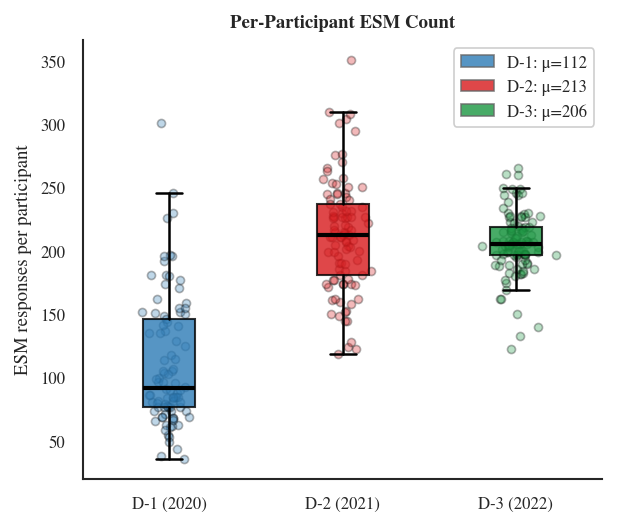

In [4]:
# Build per-wave arrays of response counts; drop empty waves
esm_series  = [esm_counts_per_person(esm_by_wave[k]) for k in WAVE_KEYS]
valid_mask  = [arr.size > 0 for arr in esm_series]
esm_series  = [arr  for arr, ok in zip(esm_series,  valid_mask) if ok]
active_keys = [key  for key, ok in zip(WAVE_KEYS,   valid_mask) if ok]
active_lbls = [lbl  for lbl, ok in zip(WAVE_LABELS, valid_mask) if ok]

fig, ax = plt.subplots(figsize=(4.0, 3.4), constrained_layout=True)

if esm_series:
    bp = ax.boxplot(
        esm_series, patch_artist=True, showfliers=False,
        medianprops=dict(color="black", lw=2),
        whiskerprops=dict(lw=1.2),
        capprops=dict(lw=1.2),
    )
    for patch, key in zip(bp["boxes"], active_keys):
        patch.set_facecolor(COLORS[key])
        patch.set_alpha(0.8)

    np.random.seed(42)
    for i, arr in enumerate(esm_series, start=1):
        x = np.random.normal(loc=i, scale=0.06, size=len(arr))
        ax.scatter(x, arr, s=15, alpha=0.3, color=COLORS[active_keys[i - 1]], edgecolors="black")    
    
    ax.set_xticks(range(1, len(active_lbls) + 1))
    ax.set_xticklabels(active_lbls)
    ax.set_ylabel("ESM responses per participant")
    ax.set_title("Per-Participant ESM Count", fontweight="bold", fontsize=9)

    legend_handles = [
        mpatches.Patch(
            facecolor=COLORS[active_keys[i]], alpha=0.8, edgecolor="0.4",
            label=f"{active_keys[i]}: μ={np.mean(esm_series[i]):.0f}",
        )
        for i in range(len(esm_series))
    ]
    ax.legend(handles=legend_handles, loc="upper right", fontsize=8,
              frameon=True, framealpha=0.95)
else:
    ax.text(0.5, 0.5, "no data", ha="center", va="center",
            transform=ax.transAxes, color="gray")
    ax.set_axis_off()

plt.show()

### Daily Response Rate by Study Day

This line plot shows per-participant ESM response rate across study days for each wave.


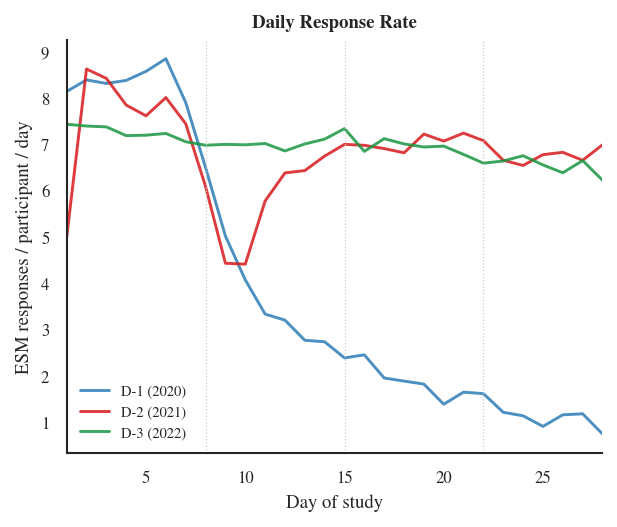

In [5]:
WEEK_BOUNDARIES = [8, 15, 22]   # day numbers marking week boundaries
STUDY_DAYS      = np.arange(1, 29)

fig, ax = plt.subplots(figsize=(4.0, 3.4), constrained_layout=True)

for k_idx, wave in enumerate(WAVE_KEYS):
    if esm_all.empty or "study_day" not in esm_all.columns:
        continue
    sub = esm_all[esm_all["Wave"] == wave]
    n_participants = sub["Pcode"].nunique()
    daily_rate = (
        sub.groupby("study_day").size()
           .reindex(STUDY_DAYS, fill_value=0)
           .div(n_participants)
    )
    ax.plot(STUDY_DAYS, daily_rate.values,
            color=COLORS[wave], lw=1.4, alpha=0.85, label=WAVE_LABELS[k_idx])

for w in WEEK_BOUNDARIES:
    ax.axvline(w, color="#cccccc", lw=0.6, ls=":")

ax.set_xlabel("Day of study")
ax.set_ylabel("ESM responses / participant / day")
ax.set_xlim(1, 28)
ax.set_title("Daily Response Rate", fontweight="bold", fontsize=9)
ax.legend(frameon=False, fontsize=7)
plt.show()

### Daily activity heatmap

This heatmap summarizes the pattern across waves so differences and missingness are easy to compare.


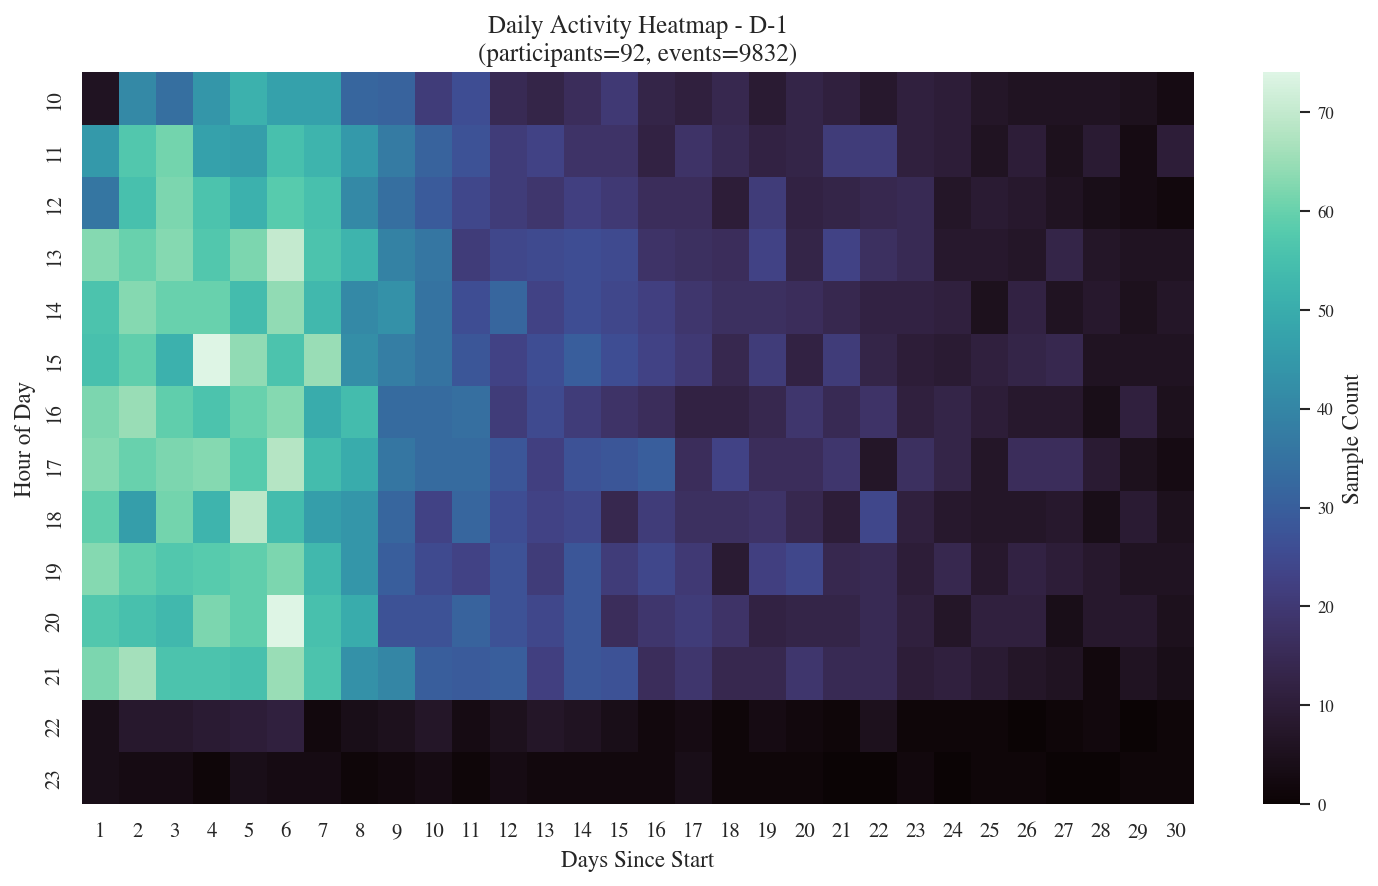

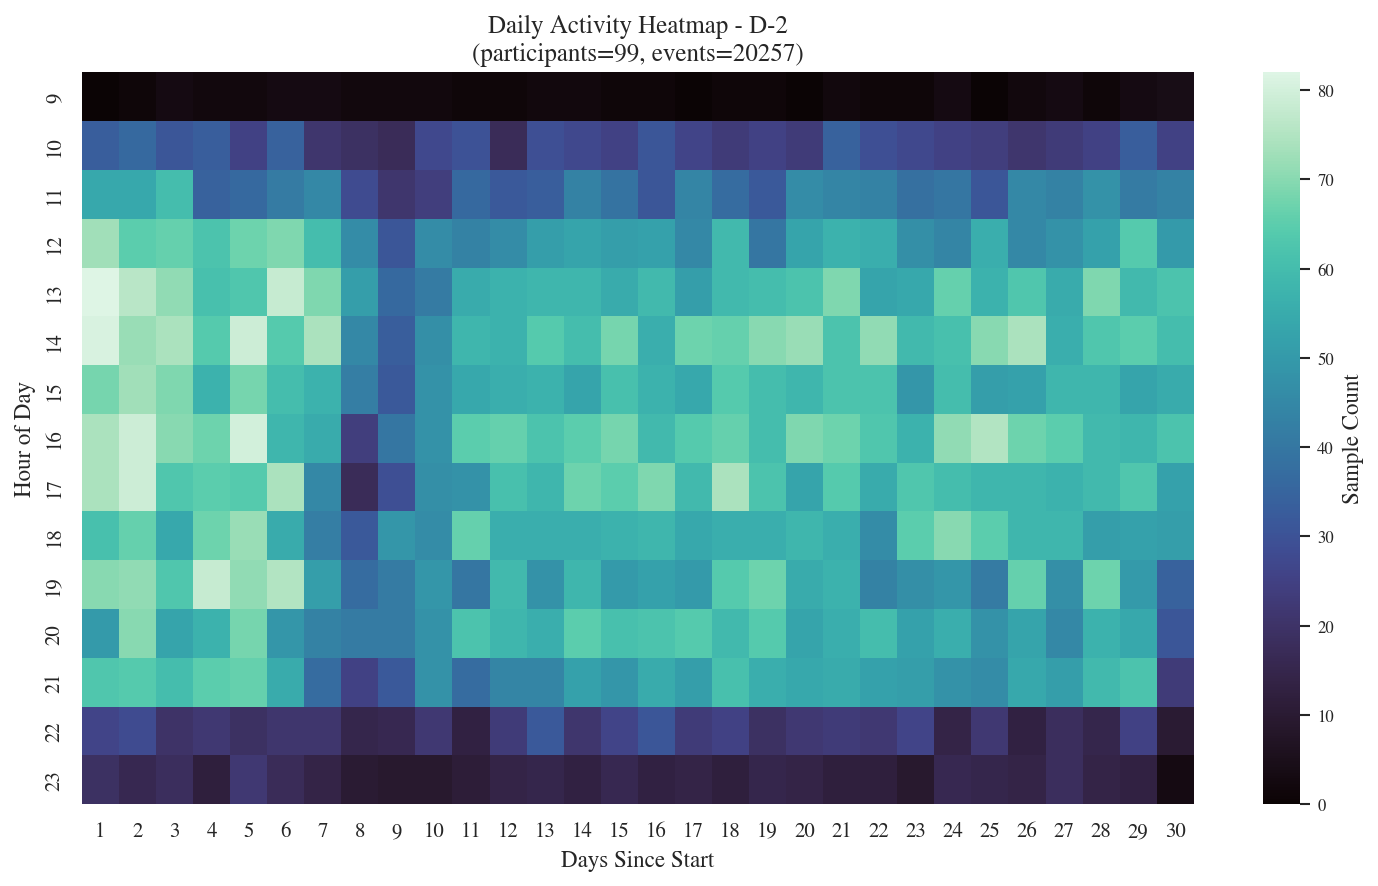

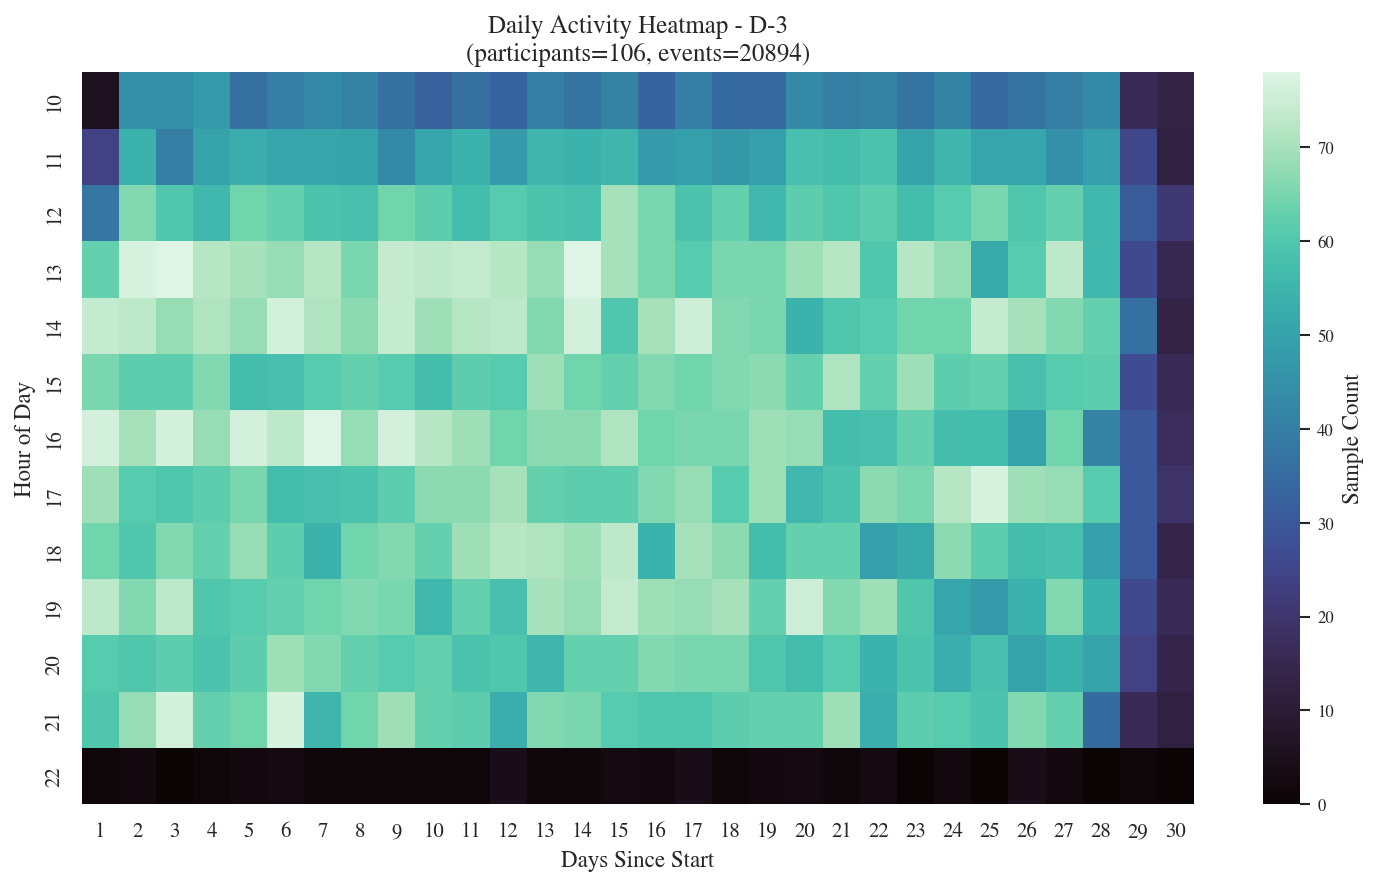

In [7]:
ds_col  = "META#dataset"
ts_col  = "PIF#timestamp"
start_col = "PIF#participationStartTimestamp"
pid_col = "PIF#participantID"

# --- Parse both columns to timezone-aware datetimes in Asia/Seoul ---
ts_dt = pd.to_datetime(df_X_combined[ts_col], errors="coerce", utc=True).dt.tz_convert("Asia/Seoul")
start_dt = pd.to_datetime(df_X_combined[start_col], unit="ms", errors="coerce", utc=True).dt.tz_convert("Asia/Seoul")

ok = ts_dt.notna() & start_dt.notna()
base = df_X_combined.loc[ok, [ds_col, pid_col]].copy()
base = base.assign(
    datetime=ts_dt.loc[ok],
    start_dt=start_dt.loc[ok],
)

delta_days = (base["datetime"] - base["start_dt"]).dt.total_seconds() / 86400.0
base["day_index"] = np.floor(delta_days).astype("int64") + 1
base["hour"] = base["datetime"].dt.hour
base = base[(base["day_index"] >= 1) & (base["day_index"] <= 30)]

# --- run per dataset (D-1/D-2/D-3), inline plotting ---
for ds in ("D-1", "D-2", "D-3"):
    dsub = base.loc[base[ds_col] == ds, ["day_index", "hour", pid_col]]
    if dsub.empty:
        print(f"[skip] {ds}: empty after parsing")
        continue

    heat = (
        dsub.groupby(["day_index", "hour"])
            .size()
            .unstack(fill_value=0)
            .sort_index()
    )

    hour_totals = heat.sum(axis=0)
    valid_hours = hour_totals[hour_totals >= 20].index
    heat = heat[valid_hours]
    if heat.empty:
        print(f"[skip] {ds}: no hours with ≥20 samples")
        continue

    plt.figure(figsize=(10, 6))
    ax = sns.heatmap(
        heat.T, cmap="mako", cbar_kws={"label": "Sample Count"},
        square=False,
    )
    cbar = ax.collections[0].colorbar
    cbar.set_label("Sample Count", fontsize=11)

    plt.title(
        f"Daily Activity Heatmap - {ds}\n"
        f"(participants={dsub[pid_col].nunique()}, events={len(dsub)})",
        fontsize=12,
    )
    ax.tick_params(axis="x", labelsize=10)
    ax.tick_params(axis="y", labelsize=10)
    plt.xlabel("Days Since Start", fontsize=11)
    plt.ylabel("Hour of Day", fontsize=11)
    plt.tight_layout()
    plt.show()

### Daily Activity Heatmap (Combined Datasets)

This heatmap aggregates all datasets to show activity intensity by study day and hour.


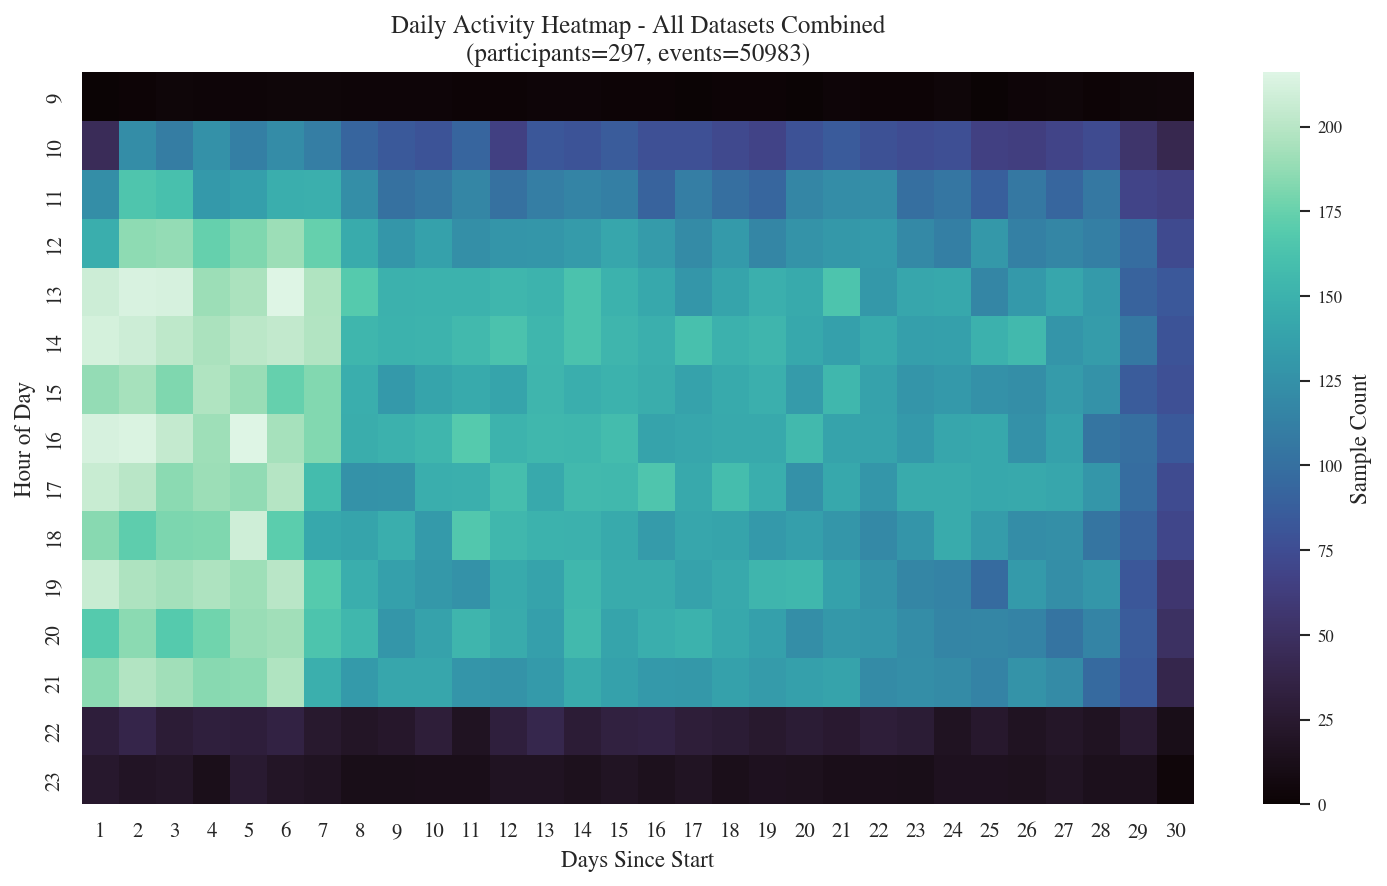

In [8]:
# --- Combined heatmap (all datasets), inline plotting ---
base_combined = base.copy()
base_combined["PIF#participantID"] = base_combined[ds_col] + '_' + base_combined[pid_col].astype(str)

if base_combined.empty:
    print("[skip] All Datasets Combined: empty after parsing")
else:
    heat = (
        base_combined.groupby(["day_index", "hour"])
            .size()
            .unstack(fill_value=0)
            .sort_index()
    )

    hour_totals = heat.sum(axis=0)
    valid_hours = hour_totals[hour_totals >= 20].index
    heat = heat[valid_hours]

    if heat.empty:
        print("[skip] All Datasets Combined: no hours with ≥20 samples")
    else:
        plt.figure(figsize=(10, 6))
        ax = sns.heatmap(
            heat.T, cmap="mako", cbar_kws={"label": "Sample Count"},
            square=False,
        )
        cbar = ax.collections[0].colorbar
        cbar.set_label("Sample Count", fontsize=11)

        plt.title(
            f"Daily Activity Heatmap - All Datasets Combined\n"
            f"(participants={base_combined['PIF#participantID'].nunique()}, events={len(base_combined)})",
            fontsize=12,
        )
        ax.tick_params(axis="x", labelsize=10)
        ax.tick_params(axis="y", labelsize=10)
        plt.xlabel("Days Since Start", fontsize=11)
        plt.ylabel("Hour of Day", fontsize=11)
        plt.tight_layout()
        plt.show()

### Prompt to response delay distribution

This line-based view shows how the metric changes across waves, study days, or participant groups.


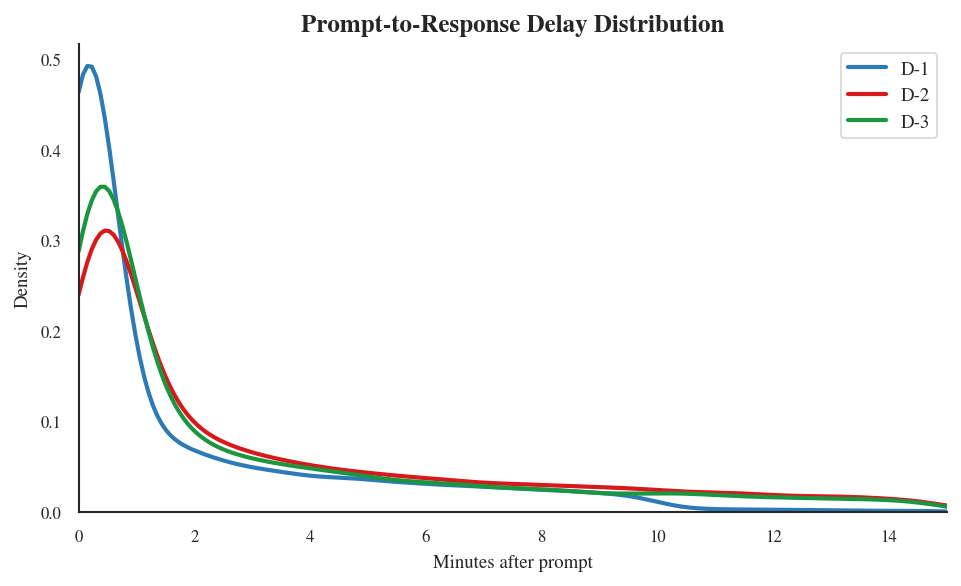

In [9]:
fig, ax = plt.subplots(figsize=(6.5, 4.0))
esm_by_ds = {}
for name, df in esm_by_wave.items():
    if df.empty:
        continue
    if "TriggerTime" not in df.columns or "ReactionTime" not in df.columns:
        continue
    dsub = df.dropna(subset=["TriggerTime", "ReactionTime"]).copy()
    dsub["response_delay_min"] = (dsub["ReactionTime"] - dsub["TriggerTime"]).dt.total_seconds() / 60
    dsub = dsub[dsub["response_delay_min"] > 0]
    esm_by_ds[name] = dsub
all_delays = pd.concat([d["response_delay_min"] for d in esm_by_ds.values()], ignore_index=True)
x_max = all_delays.max()
# np.nanpercentile(all_delays, 95) if len(all_delays) else 60
for name, df in esm_by_ds.items():
    delays = df["response_delay_min"]
    if len(delays) > 1:
        sns.kdeplot(
            delays, ax=ax, color=COLORS[name],
            linewidth=2, label=name, bw_adjust=1.1, clip=(0, x_max)
        )
ax.set_title("Prompt-to-Response Delay Distribution", fontsize=12, fontweight="bold")
ax.set_xlabel("Minutes after prompt")
ax.set_ylabel("Density")
ax.set_xlim(0, x_max)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()